In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import shap
import joblib, os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 300, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 11, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
})

PROC   = '../data/processed/'
MODELS = '../models/'
FIG    = '../paper/figures/'
RES    = '../results/'

# Load data
X_train    = np.load(PROC + 'X_train_res.npy')
y_train    = np.load(PROC + 'y_train_res.npy')
X_val      = np.load(PROC + 'X_val_scaled.npy')
y_val      = np.load(PROC + 'y_val.npy')
feat_names = pd.read_csv(PROC + 'feature_names.csv', header=None)[0].tolist()

# Load both primary models
lr_model = joblib.load(MODELS + 'logistic_regression.pkl')
rf_model = joblib.load(MODELS + 'random_forest.pkl')
scaler   = joblib.load(MODELS + 'scaler.pkl')

print(f"X_val shape:    {X_val.shape}")
print(f"y_val shape:    {y_val.shape}")
print(f"Feature count:  {len(feat_names)}")
print(f"Fraud in val:   {y_val.sum()} / {len(y_val)}")
print()
print("Features loaded:")
for i, f in enumerate(feat_names, 1):
    print(f"  {i:>2}. {f}")

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


X_val shape:    (1082, 47)
y_val shape:    (1082,)
Feature count:  47
Fraud in val:   101 / 1082

Features loaded:
   1. IP_NumClaims
   2. IP_NumUniqueBeneficiaries
   3. IP_NumUniqueAttPhysicians
   4. IP_NumUniqueOpPhysicians
   5. IP_NumUniqueOthPhysicians
   6. IP_TotalClaimAmt
   7. IP_AvgClaimAmt
   8. IP_MaxClaimAmt
   9. IP_StdClaimAmt
  10. IP_TotalDeductible
  11. IP_AvgDeductible
  12. IP_AvgStayDuration
  13. IP_MaxStayDuration
  14. IP_TotalStayDays
  15. IP_AvgClaimDuration
  16. IP_AvgDiagnosisCodes
  17. IP_AvgProcedureCodes
  18. IP_AvgPatientAge
  19. IP_PctDeadPatients
  20. IP_AvgChronicConditions
  21. IP_PctRenalDisease
  22. IP_AvgGender
  23. IP_AvgIPAnnualReimb
  24. IP_AvgOPAnnualReimb
  25. OP_NumClaims
  26. OP_NumUniqueBeneficiaries
  27. OP_NumUniqueAttPhysicians
  28. OP_TotalClaimAmt
  29. OP_AvgClaimAmt
  30. OP_MaxClaimAmt
  31. OP_StdClaimAmt
  32. OP_TotalDeductible
  33. OP_AvgClaimDuration
  34. OP_AvgDiagnosisCodes
  35. OP_AvgPatientAge
  36. OP

In [3]:
print("Computing SHAP values...")
print()

# ── Logistic Regression — LinearExplainer (exact) ──────────────
print("LR: Using LinearExplainer (exact computation)...")
lr_explainer   = shap.LinearExplainer(lr_model, X_train)
lr_shap_values = lr_explainer.shap_values(X_val)

print(f"  LR SHAP values shape: {lr_shap_values.shape}")
print(f"  LR expected value:    {lr_explainer.expected_value:.4f}")

# ── Random Forest — TreeExplainer (fast tree-based) ────────────
print()
print("RF: Using TreeExplainer (tree-based computation)...")
rf_explainer   = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_val)

# TreeExplainer returns different formats depending on SHAP version
# We want class 1 (fraud)
if isinstance(rf_shap_values, list):
    rf_shap_fraud = rf_shap_values[1]

elif len(rf_shap_values.shape) == 3:
    rf_shap_fraud = rf_shap_values[:, :, 1]

else:
    rf_shap_fraud = rf_shap_values

print(f"  RF SHAP values shape: {rf_shap_fraud.shape}")

# Handle expected value formatting
if isinstance(rf_explainer.expected_value, (list, np.ndarray)):
    print(f"  RF expected value:    {rf_explainer.expected_value[1]:.4f}")
else:
    print(f"  RF expected value:    {rf_explainer.expected_value:.4f}")

# ── Mean absolute SHAP — global feature importance ─────────────
lr_mean_shap = np.abs(lr_shap_values).mean(axis=0)
rf_mean_shap = np.abs(rf_shap_fraud).mean(axis=0)

# Top 15 features for each
lr_top15_idx = np.argsort(lr_mean_shap)[::-1][:15]
rf_top15_idx = np.argsort(rf_mean_shap)[::-1][:15]

print()
print("Top 10 features by mean |SHAP| — Logistic Regression:")
for i in lr_top15_idx[:10]:
    print(f"  {feat_names[i]:<40}: {lr_mean_shap[i]:.4f}")

print()
print("Top 10 features by mean |SHAP| — Random Forest:")
for i in rf_top15_idx[:10]:
    print(f"  {feat_names[i]:<40}: {rf_mean_shap[i]:.4f}")

Computing SHAP values...

LR: Using LinearExplainer (exact computation)...
  LR SHAP values shape: (1082, 47)
  LR expected value:    0.3838

RF: Using TreeExplainer (tree-based computation)...
  RF SHAP values shape: (1082, 47)
  RF expected value:    0.5005

Top 10 features by mean |SHAP| — Logistic Regression:
  IP_TotalStayDays                        : 3.2902
  IP_NumUniqueBeneficiaries               : 2.9287
  IP_TotalClaimAmt                        : 2.7149
  IP_MaxStayDuration                      : 2.6530
  Total_ClaimAmt                          : 2.2807
  IP_ClaimsPerPatient                     : 1.8432
  IP_AvgDiagnosisCodes                    : 1.5800
  OP_NumClaims                            : 1.3739
  IP_AvgStayDuration                      : 1.1653
  IP_AvgClaimAmt                          : 1.1563

Top 10 features by mean |SHAP| — Random Forest:
  IP_MaxStayDuration                      : 0.0660
  Total_ClaimAmt                          : 0.0462
  IP_TotalStayDays      

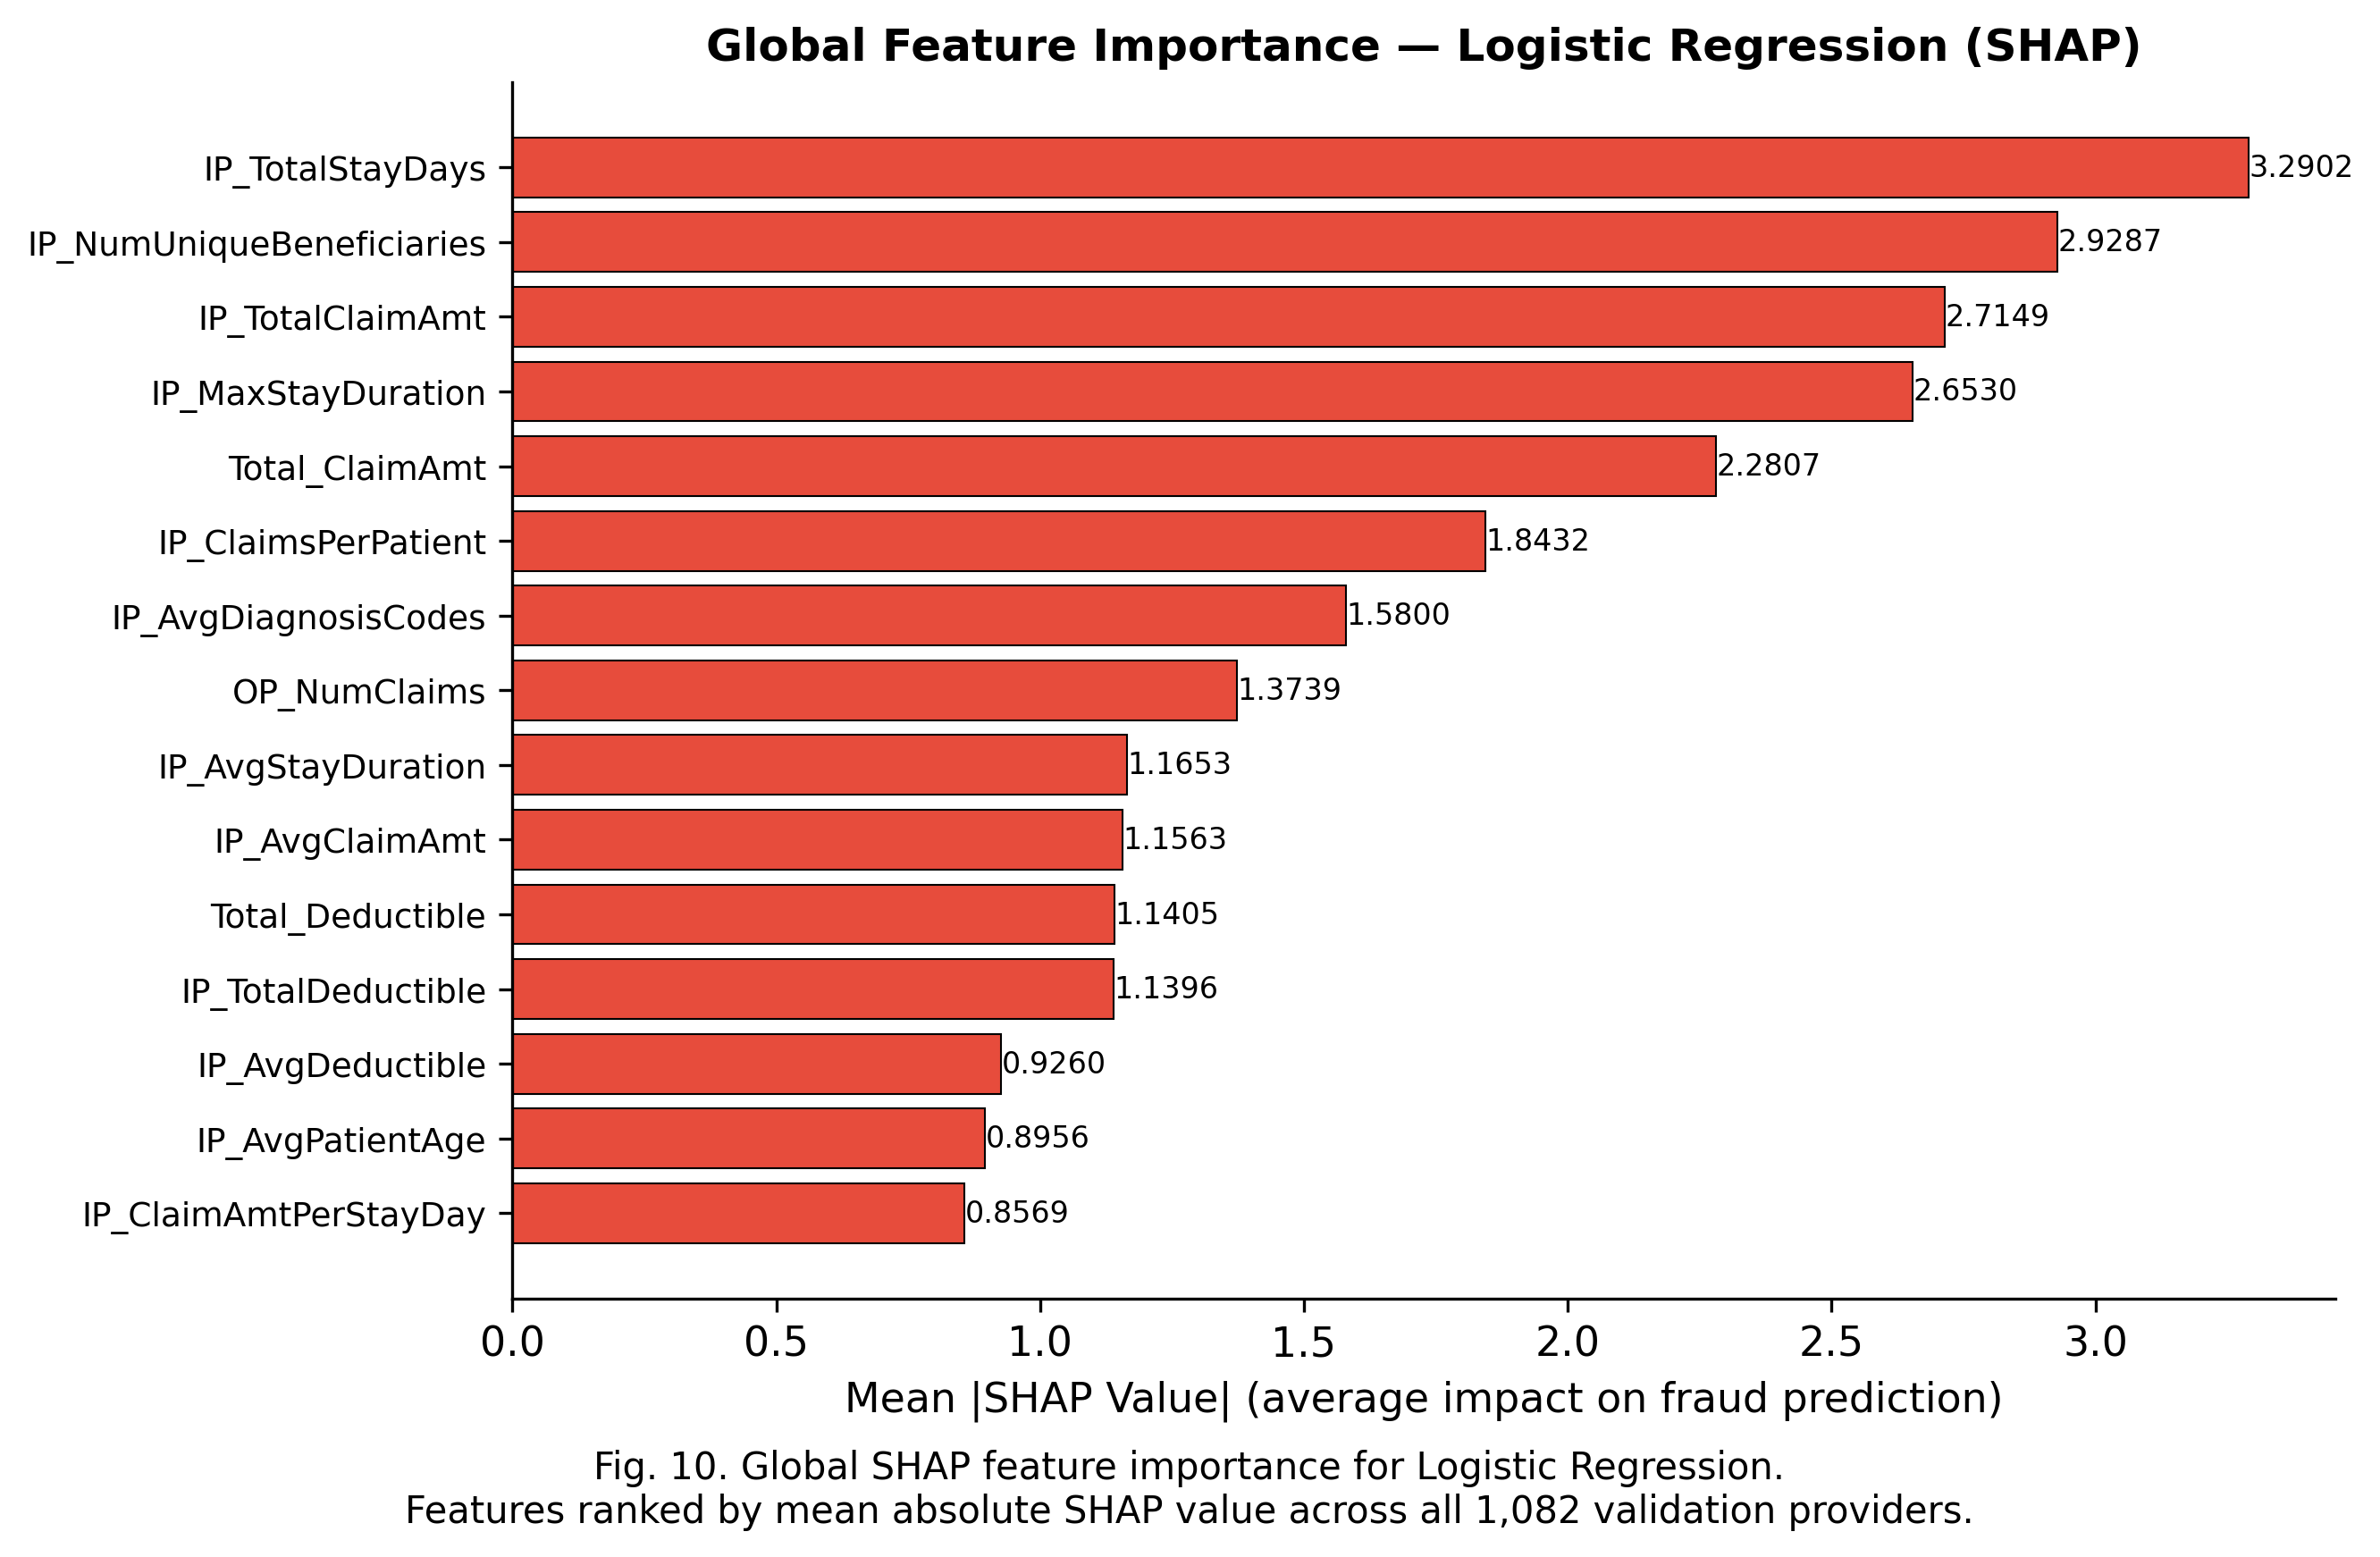

Saved: ../paper/figures/fig10_shap_global_lr.png


In [4]:
fig, ax = plt.subplots(figsize=(9, 6))

top_idx    = lr_top15_idx
top_names  = [feat_names[i] for i in top_idx]
top_values = lr_mean_shap[top_idx]
colors     = ['#e74c3c' if v > 0 else '#3498db'
              for v in [lr_explainer.expected_value] * len(top_idx)]

bars = ax.barh(range(len(top_idx)), top_values,
               color='#e74c3c', edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(top_idx)))
ax.set_yticklabels(top_names, fontsize=9)
ax.set_xlabel('Mean |SHAP Value| (average impact on fraud prediction)')
ax.set_title('Global Feature Importance — Logistic Regression (SHAP)')
ax.invert_yaxis()

for bar, val in zip(bars, top_values):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

fig.suptitle(
    'Fig. 10. Global SHAP feature importance for Logistic Regression.\n'
    'Features ranked by mean absolute SHAP value across all 1,082 validation providers.',
    fontsize=10, y=0.01
)
plt.tight_layout()
plt.savefig(FIG + 'fig10_shap_global_lr.png')
plt.show()
print(f"Saved: {FIG}fig10_shap_global_lr.png")

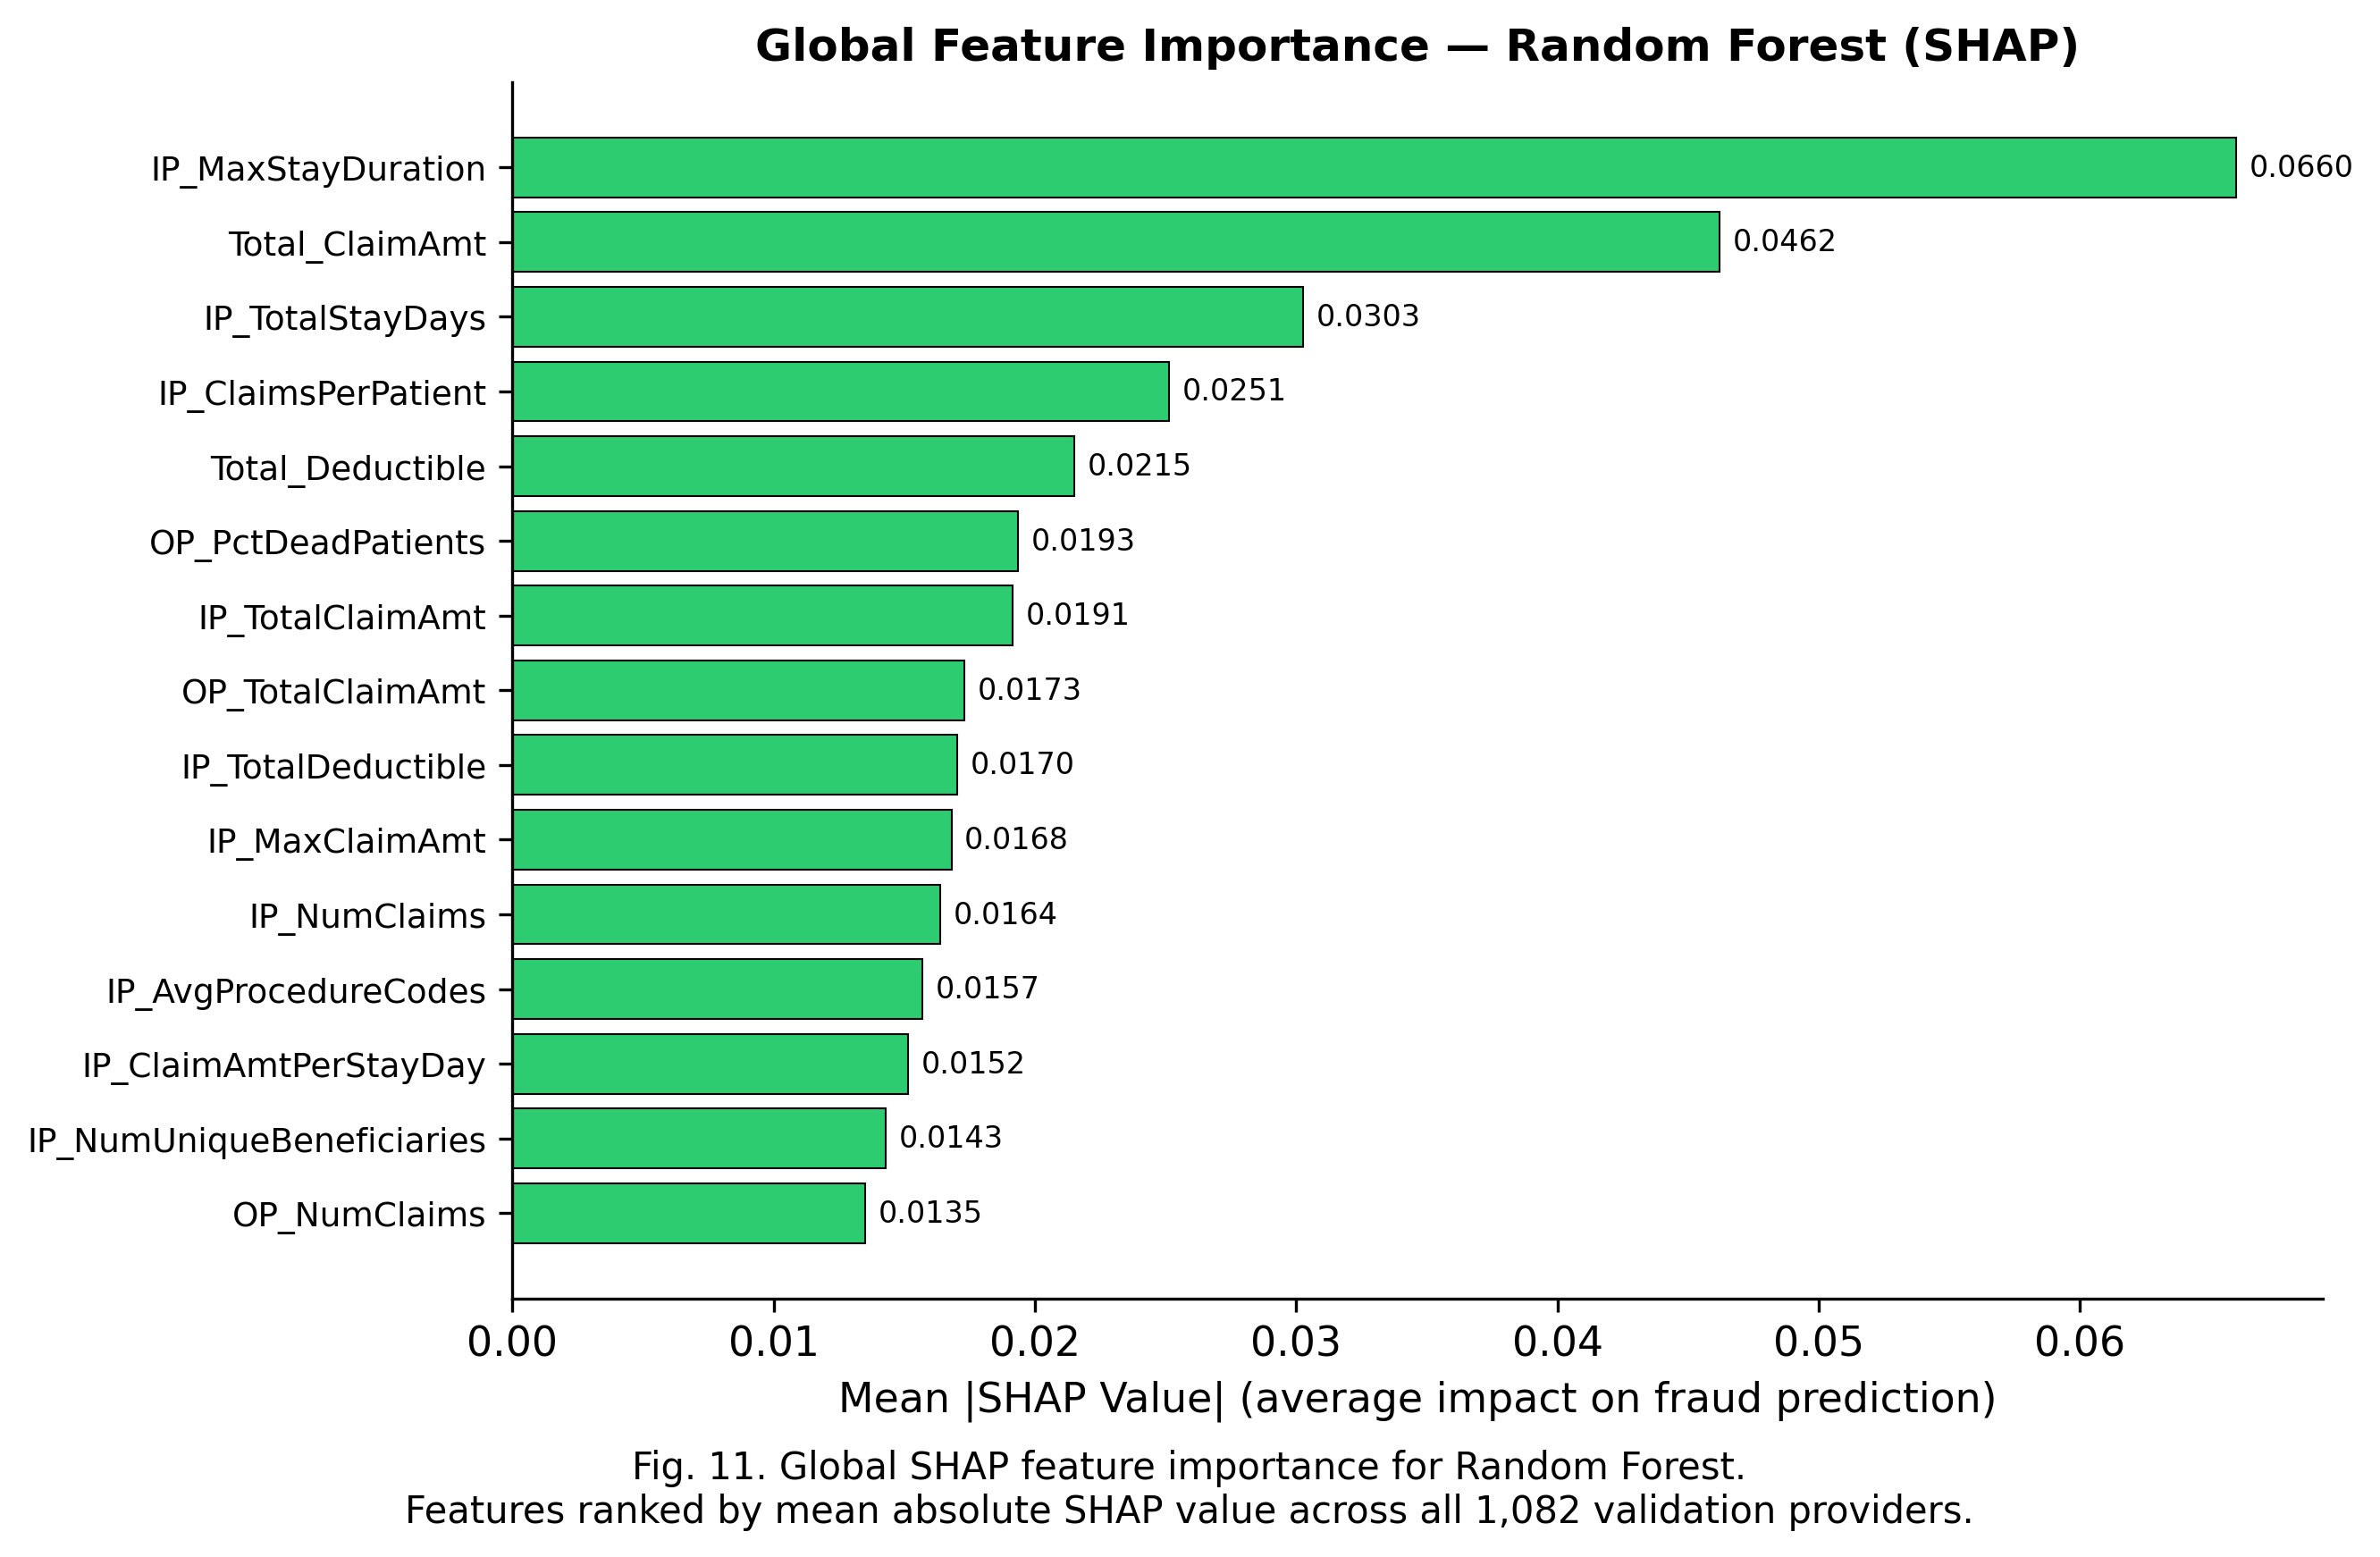

Saved: ../paper/figures/fig11_shap_global_rf.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

top_idx_rf   = rf_top15_idx
top_names_rf = [feat_names[i] for i in top_idx_rf]
top_vals_rf  = rf_mean_shap[top_idx_rf]

bars = ax.barh(range(len(top_idx_rf)), top_vals_rf,
               color='#2ecc71', edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(top_idx_rf)))
ax.set_yticklabels(top_names_rf, fontsize=9)
ax.set_xlabel('Mean |SHAP Value| (average impact on fraud prediction)')
ax.set_title('Global Feature Importance — Random Forest (SHAP)')
ax.invert_yaxis()

for bar, val in zip(bars, top_vals_rf):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

fig.suptitle(
    'Fig. 11. Global SHAP feature importance for Random Forest.\n'
    'Features ranked by mean absolute SHAP value across all 1,082 validation providers.',
    fontsize=10, y=0.01
)
plt.tight_layout()
plt.savefig(FIG + 'fig11_shap_global_rf.png')
plt.show()
print(f"Saved: {FIG}fig11_shap_global_rf.png")

FEATURE AGREEMENT ANALYSIS — USE IN PAPER

Top 15 features in BOTH models (10 features):
  IP_ClaimAmtPerStayDay
  IP_ClaimsPerPatient
  IP_MaxStayDuration
  IP_NumUniqueBeneficiaries
  IP_TotalClaimAmt
  IP_TotalDeductible
  IP_TotalStayDays
  OP_NumClaims
  Total_ClaimAmt
  Total_Deductible

Only in LR top 15 (5):
  IP_AvgClaimAmt
  IP_AvgDeductible
  IP_AvgDiagnosisCodes
  IP_AvgPatientAge
  IP_AvgStayDuration

Only in RF top 15 (5):
  IP_AvgProcedureCodes
  IP_MaxClaimAmt
  IP_NumClaims
  OP_PctDeadPatients
  OP_TotalClaimAmt


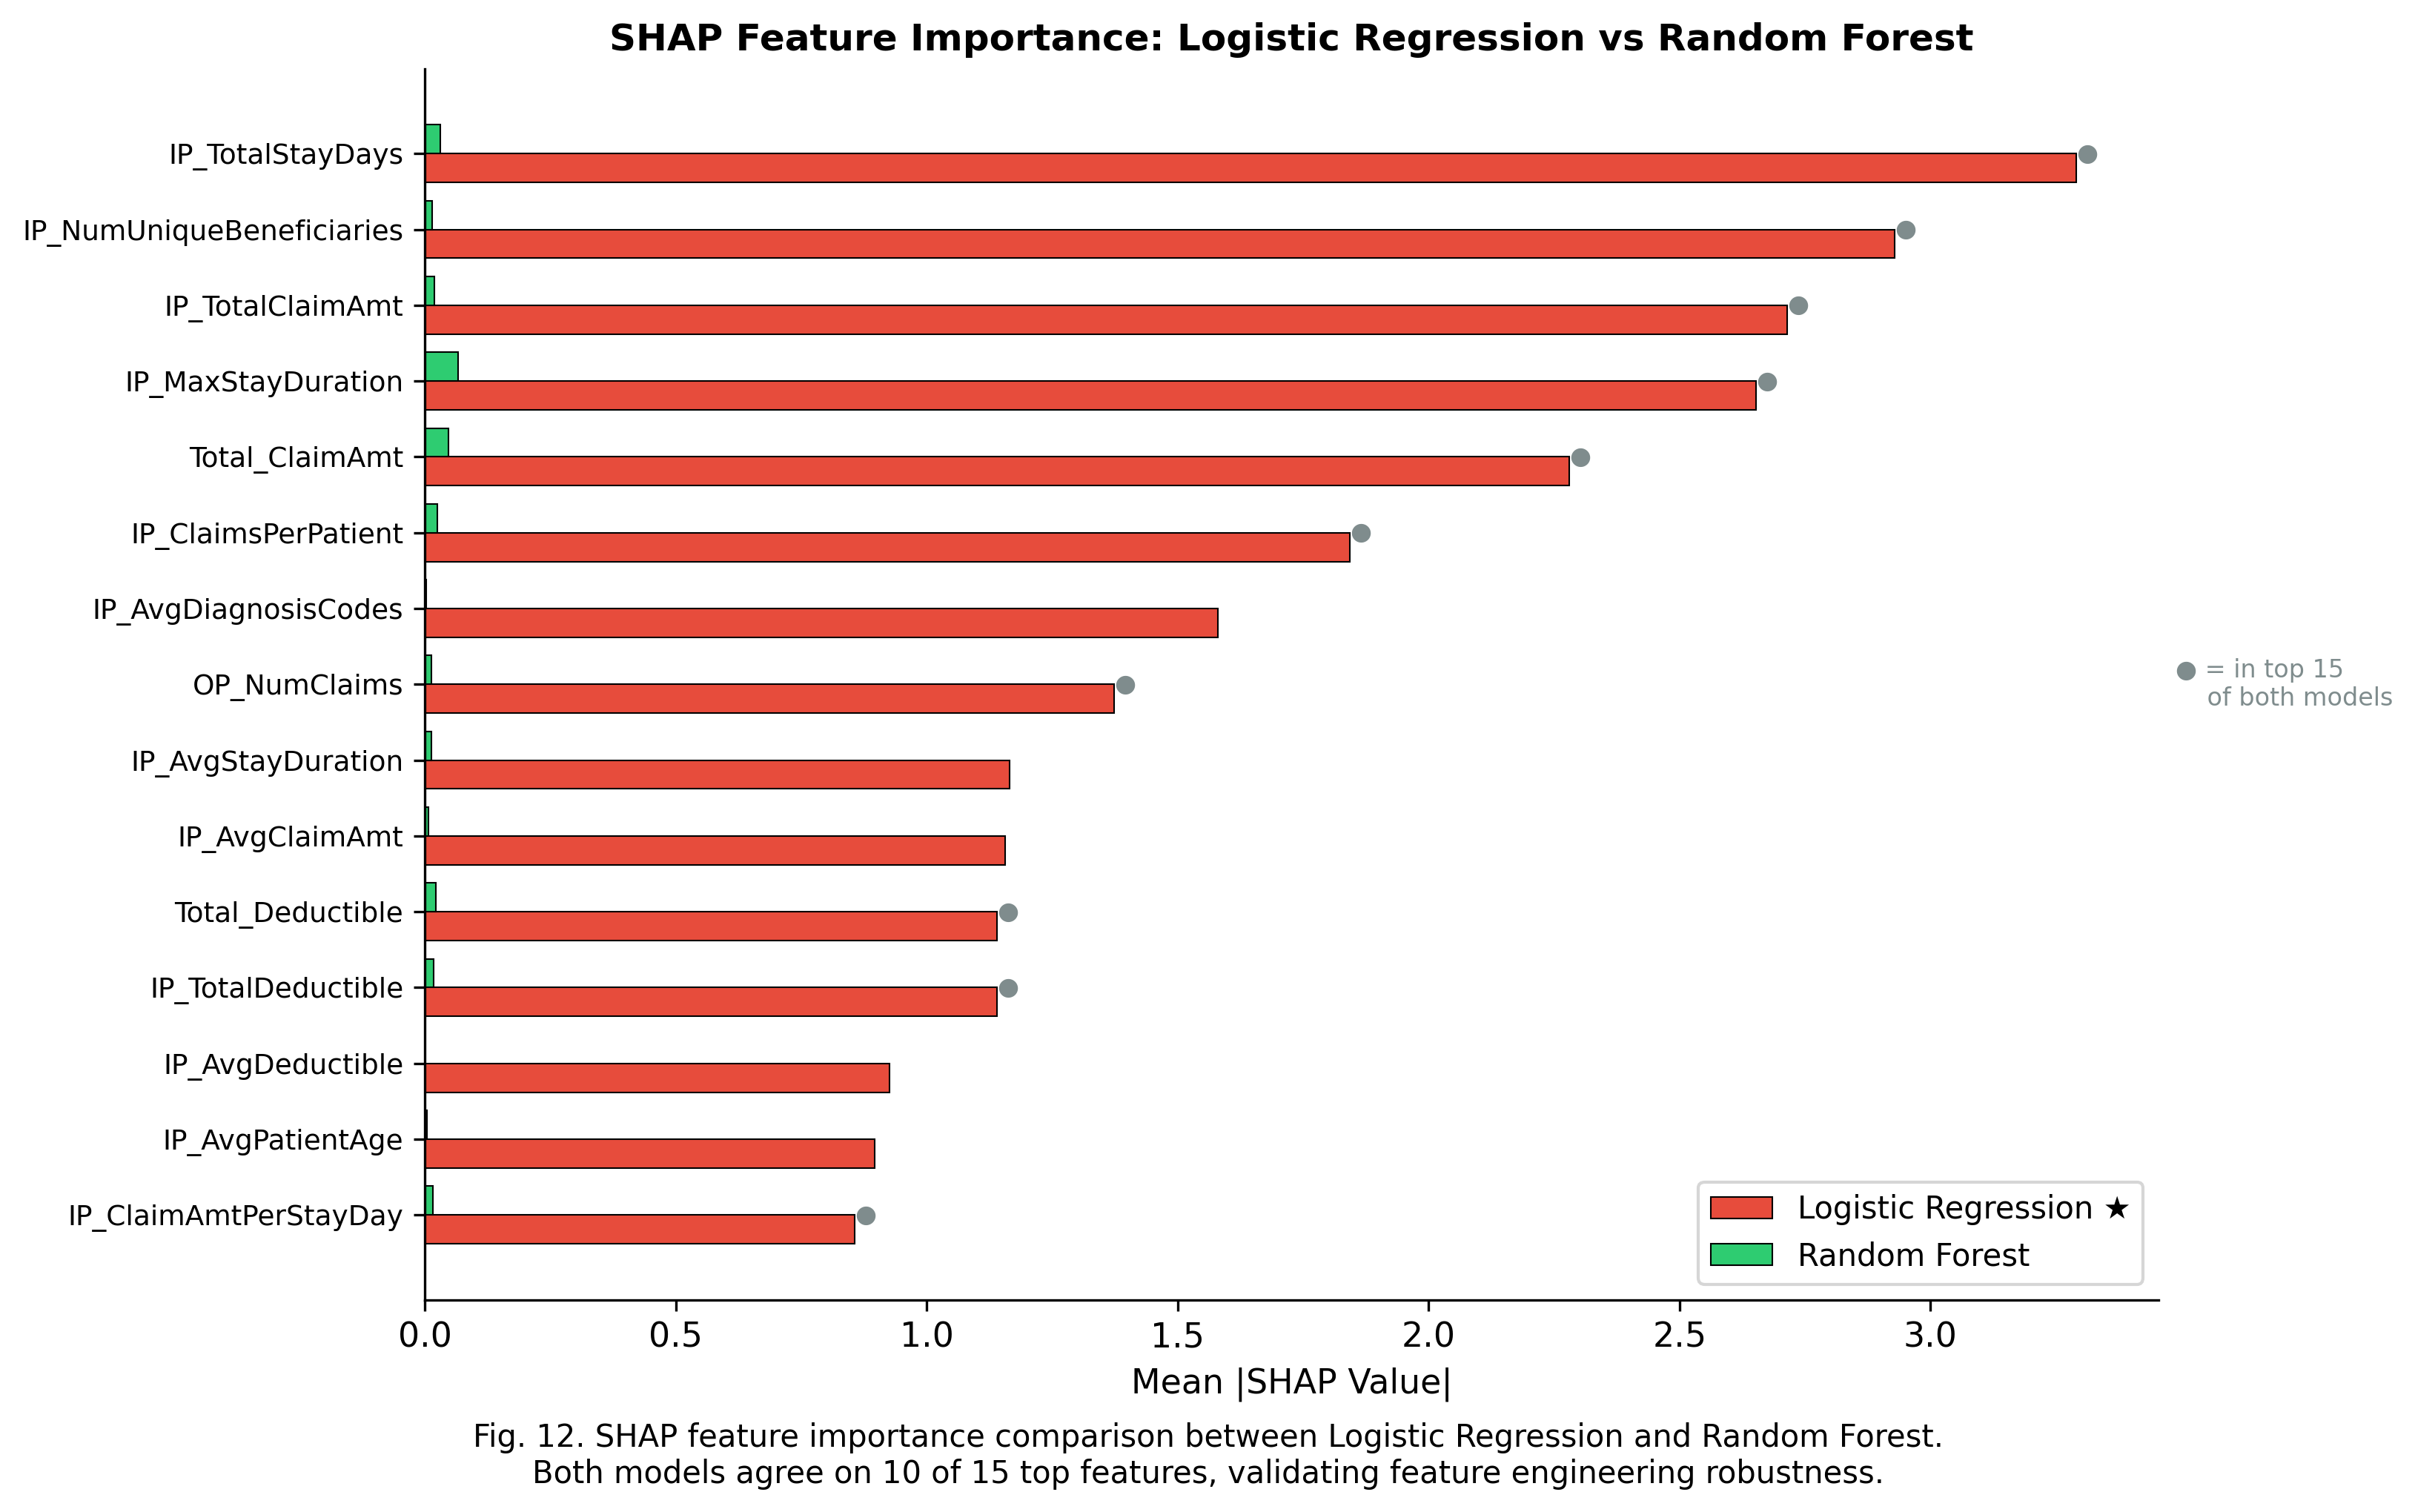

Saved: ../paper/figures/fig12_shap_comparison_lr_rf.png


In [6]:
# Find features in top 15 of BOTH models
lr_top15_names = set([feat_names[i] for i in lr_top15_idx])
rf_top15_names = set([feat_names[i] for i in rf_top15_idx])
common         = lr_top15_names & rf_top15_names
only_lr        = lr_top15_names - rf_top15_names
only_rf        = rf_top15_names - lr_top15_names

print("=" * 60)
print("FEATURE AGREEMENT ANALYSIS — USE IN PAPER")
print("=" * 60)
print(f"\nTop 15 features in BOTH models ({len(common)} features):")
for f in sorted(common):
    print(f"  {f}")
print(f"\nOnly in LR top 15 ({len(only_lr)}):")
for f in sorted(only_lr):
    print(f"  {f}")
print(f"\nOnly in RF top 15 ({len(only_rf)}):")
for f in sorted(only_rf):
    print(f"  {f}")

# Build combined top features (union, ranked by LR importance)
all_top = sorted(
    list(lr_top15_names | rf_top15_names),
    key=lambda f: lr_mean_shap[feat_names.index(f)],
    reverse=True
)[:15]

lr_vals_combined = [lr_mean_shap[feat_names.index(f)] for f in all_top]
rf_vals_combined = [rf_mean_shap[feat_names.index(f)] for f in all_top]

x   = np.arange(len(all_top))
w   = 0.38
fig, ax = plt.subplots(figsize=(11, 7))

b1 = ax.barh(x + w/2, lr_vals_combined, w,
             label='Logistic Regression ★', color='#e74c3c',
             edgecolor='black', linewidth=0.5)
b2 = ax.barh(x - w/2, rf_vals_combined, w,
             label='Random Forest', color='#2ecc71',
             edgecolor='black', linewidth=0.5)

ax.set_yticks(x)
ax.set_yticklabels(all_top, fontsize=9)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('SHAP Feature Importance: Logistic Regression vs Random Forest')
ax.invert_yaxis()
ax.legend(fontsize=10)

# Mark features common to both
for i, feat in enumerate(all_top):
    if feat in common:
        ax.text(max(lr_vals_combined[i], rf_vals_combined[i]) + 0.0003,
                i, '●', va='center', fontsize=8, color='#7f8c8d')

ax.text(1.01, 0.5, '● = in top 15\n    of both models',
        transform=ax.transAxes, fontsize=8, va='center', color='#7f8c8d')

fig.suptitle(
    'Fig. 12. SHAP feature importance comparison between Logistic Regression and Random Forest.\n'
    f'Both models agree on {len(common)} of 15 top features, validating feature engineering robustness.',
    fontsize=10, y=0.01
)
plt.tight_layout()
plt.savefig(FIG + 'fig12_shap_comparison_lr_rf.png', bbox_inches='tight')
plt.show()
print(f"Saved: {FIG}fig12_shap_comparison_lr_rf.png")

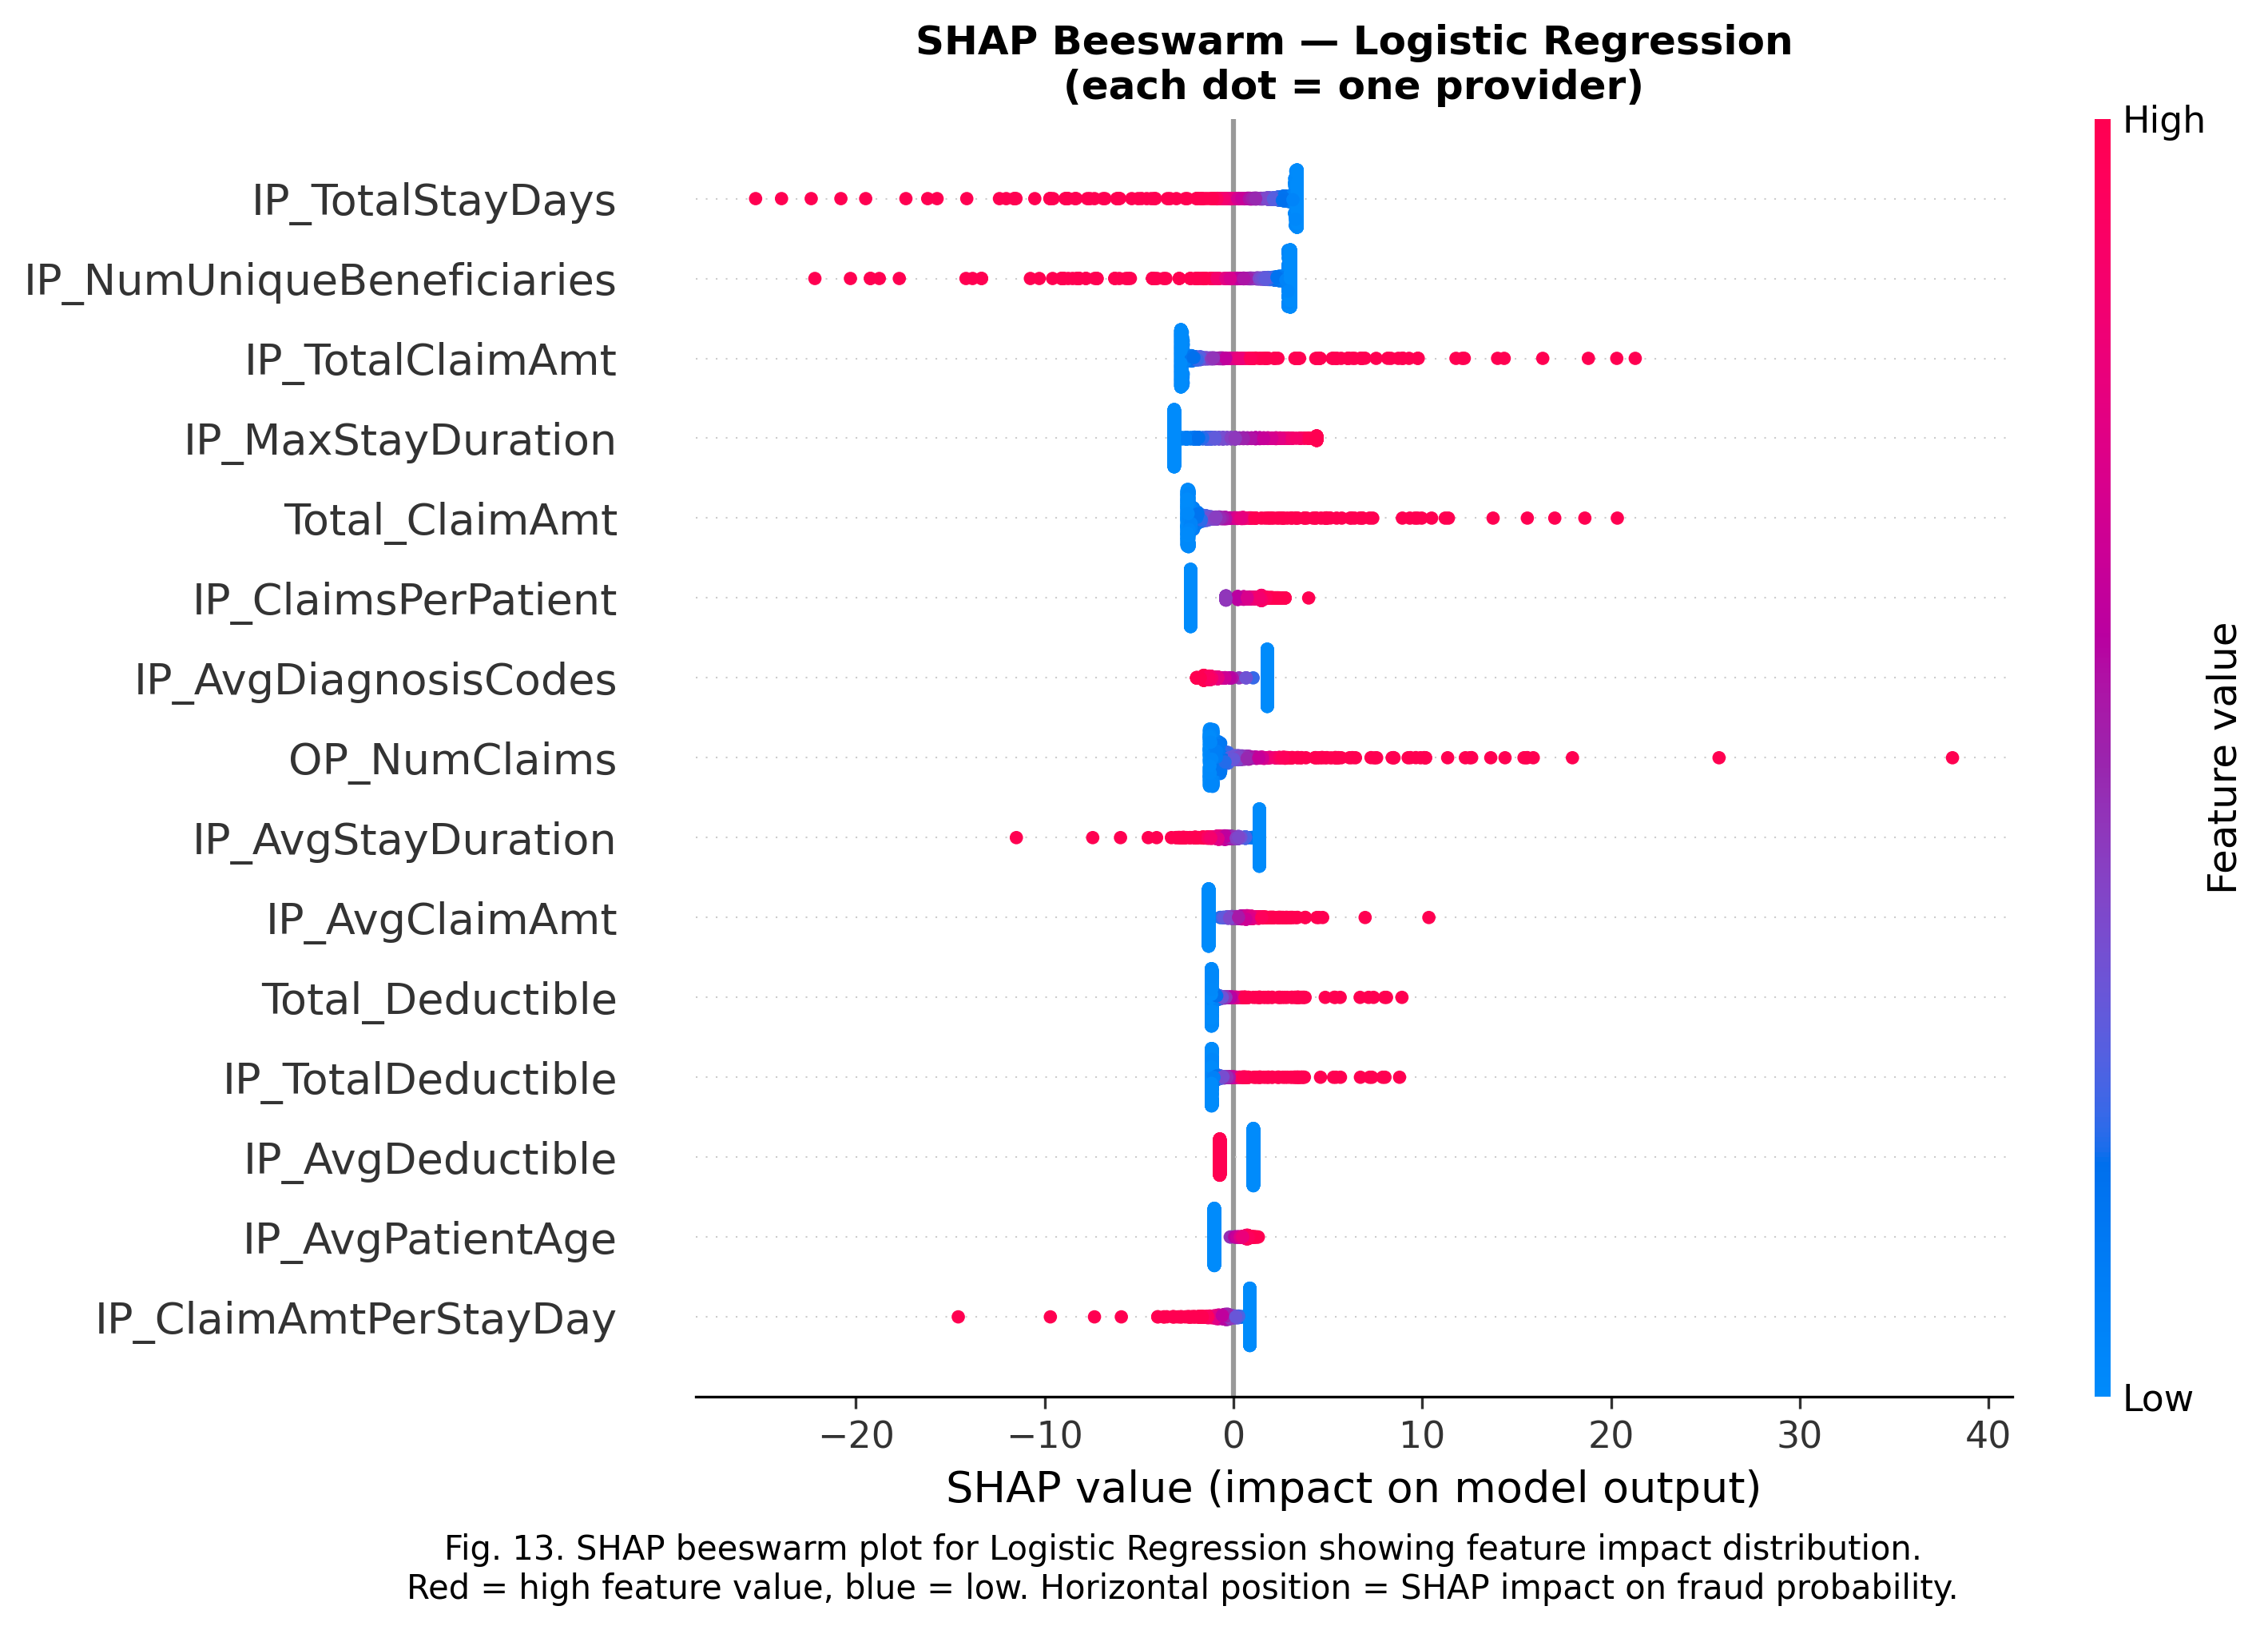

Saved: ../paper/figures/fig13_shap_beeswarm_lr.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 7))

shap.summary_plot(
    lr_shap_values,
    X_val,
    feature_names=feat_names,
    max_display=15,
    show=False,
    plot_type='dot',
    color_bar=True,
)
plt.title('SHAP Beeswarm — Logistic Regression\n(each dot = one provider)',
          fontsize=12, fontweight='bold')
plt.gcf().set_size_inches(10, 7)
plt.suptitle(
    'Fig. 13. SHAP beeswarm plot for Logistic Regression showing feature impact distribution.\n'
    'Red = high feature value, blue = low. Horizontal position = SHAP impact on fraud probability.',
    fontsize=10, y=0.01
)
plt.tight_layout()
plt.savefig(FIG + 'fig13_shap_beeswarm_lr.png')
plt.show()
print(f"Saved: {FIG}fig13_shap_beeswarm_lr.png")

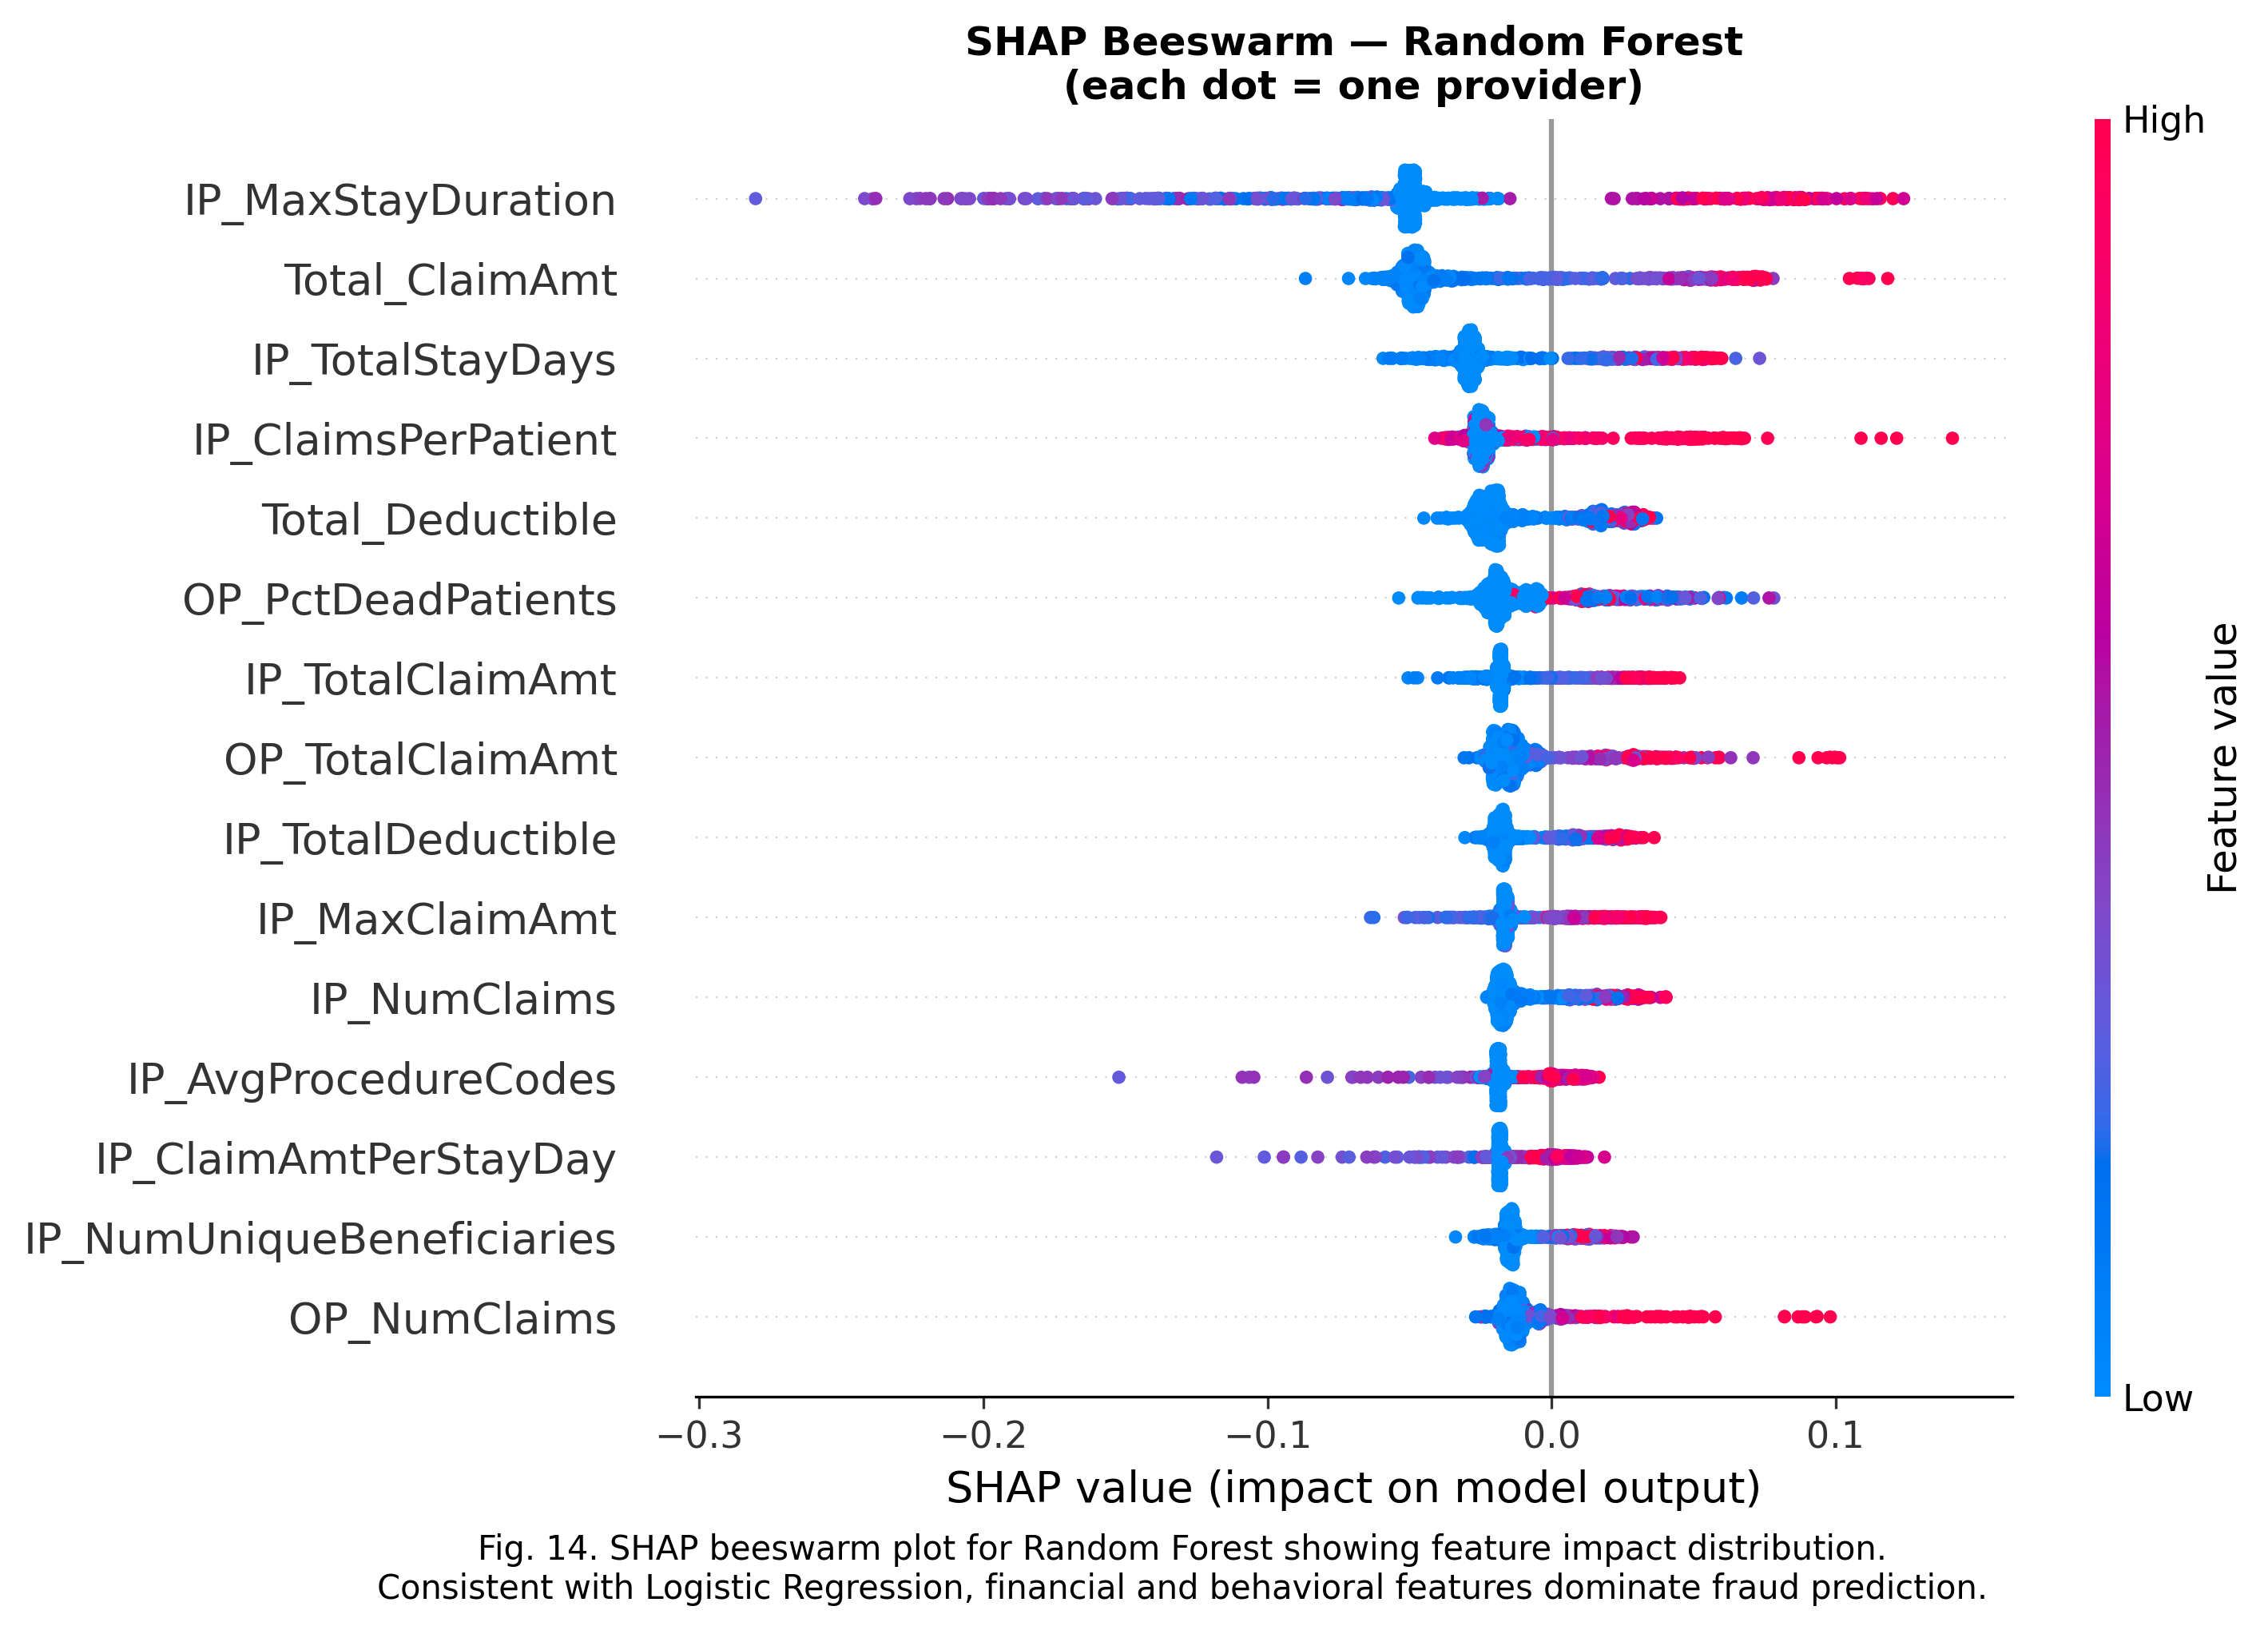

Saved: ../paper/figures/fig14_shap_beeswarm_rf.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

shap.summary_plot(
    rf_shap_fraud,
    X_val,
    feature_names=feat_names,
    max_display=15,
    show=False,
    plot_type='dot',
    color_bar=True,
)
plt.title('SHAP Beeswarm — Random Forest\n(each dot = one provider)',
          fontsize=12, fontweight='bold')
plt.gcf().set_size_inches(10, 7)
plt.suptitle(
    'Fig. 14. SHAP beeswarm plot for Random Forest showing feature impact distribution.\n'
    'Consistent with Logistic Regression, financial and behavioral features dominate fraud prediction.',
    fontsize=10, y=0.01
)
plt.tight_layout()
plt.savefig(FIG + 'fig14_shap_beeswarm_rf.png')
plt.show()
print(f"Saved: {FIG}fig14_shap_beeswarm_rf.png")

Selected fraud provider:     val index 53, fraud prob = 1.0000
Selected non-fraud provider: val index 631, fraud prob = 0.0000


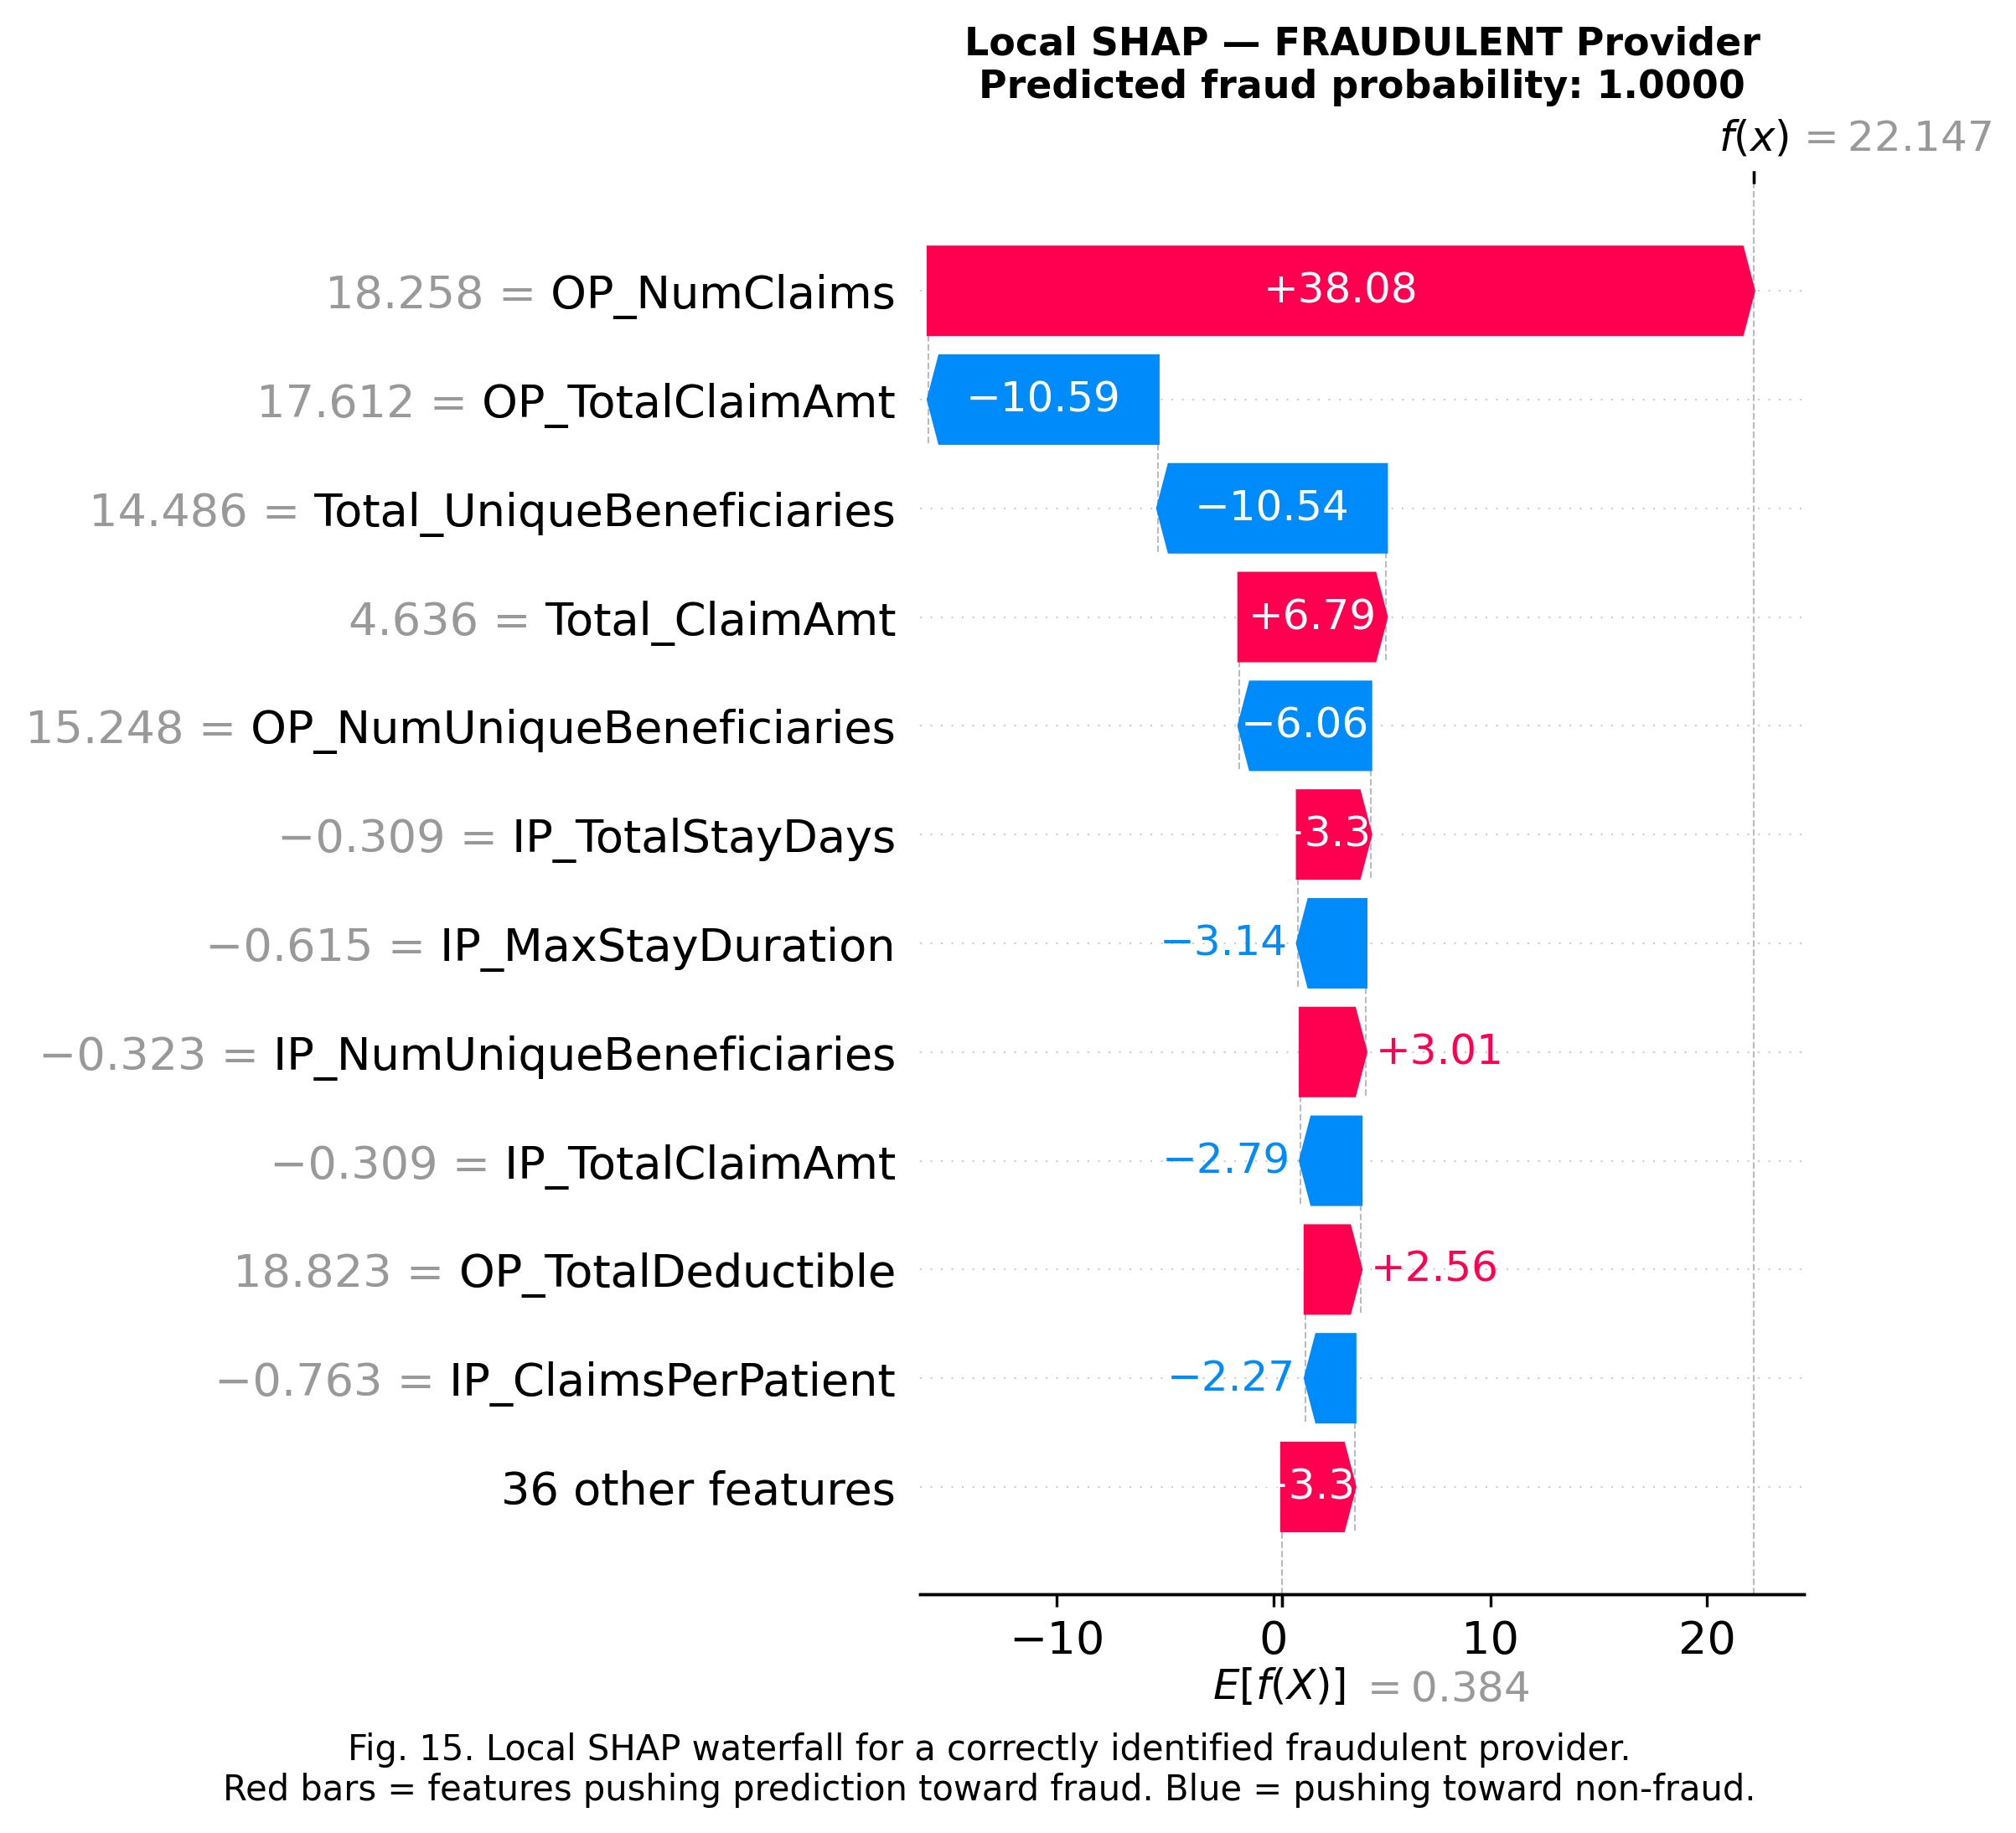

Saved: ../paper/figures/fig15_shap_local_fraud.png


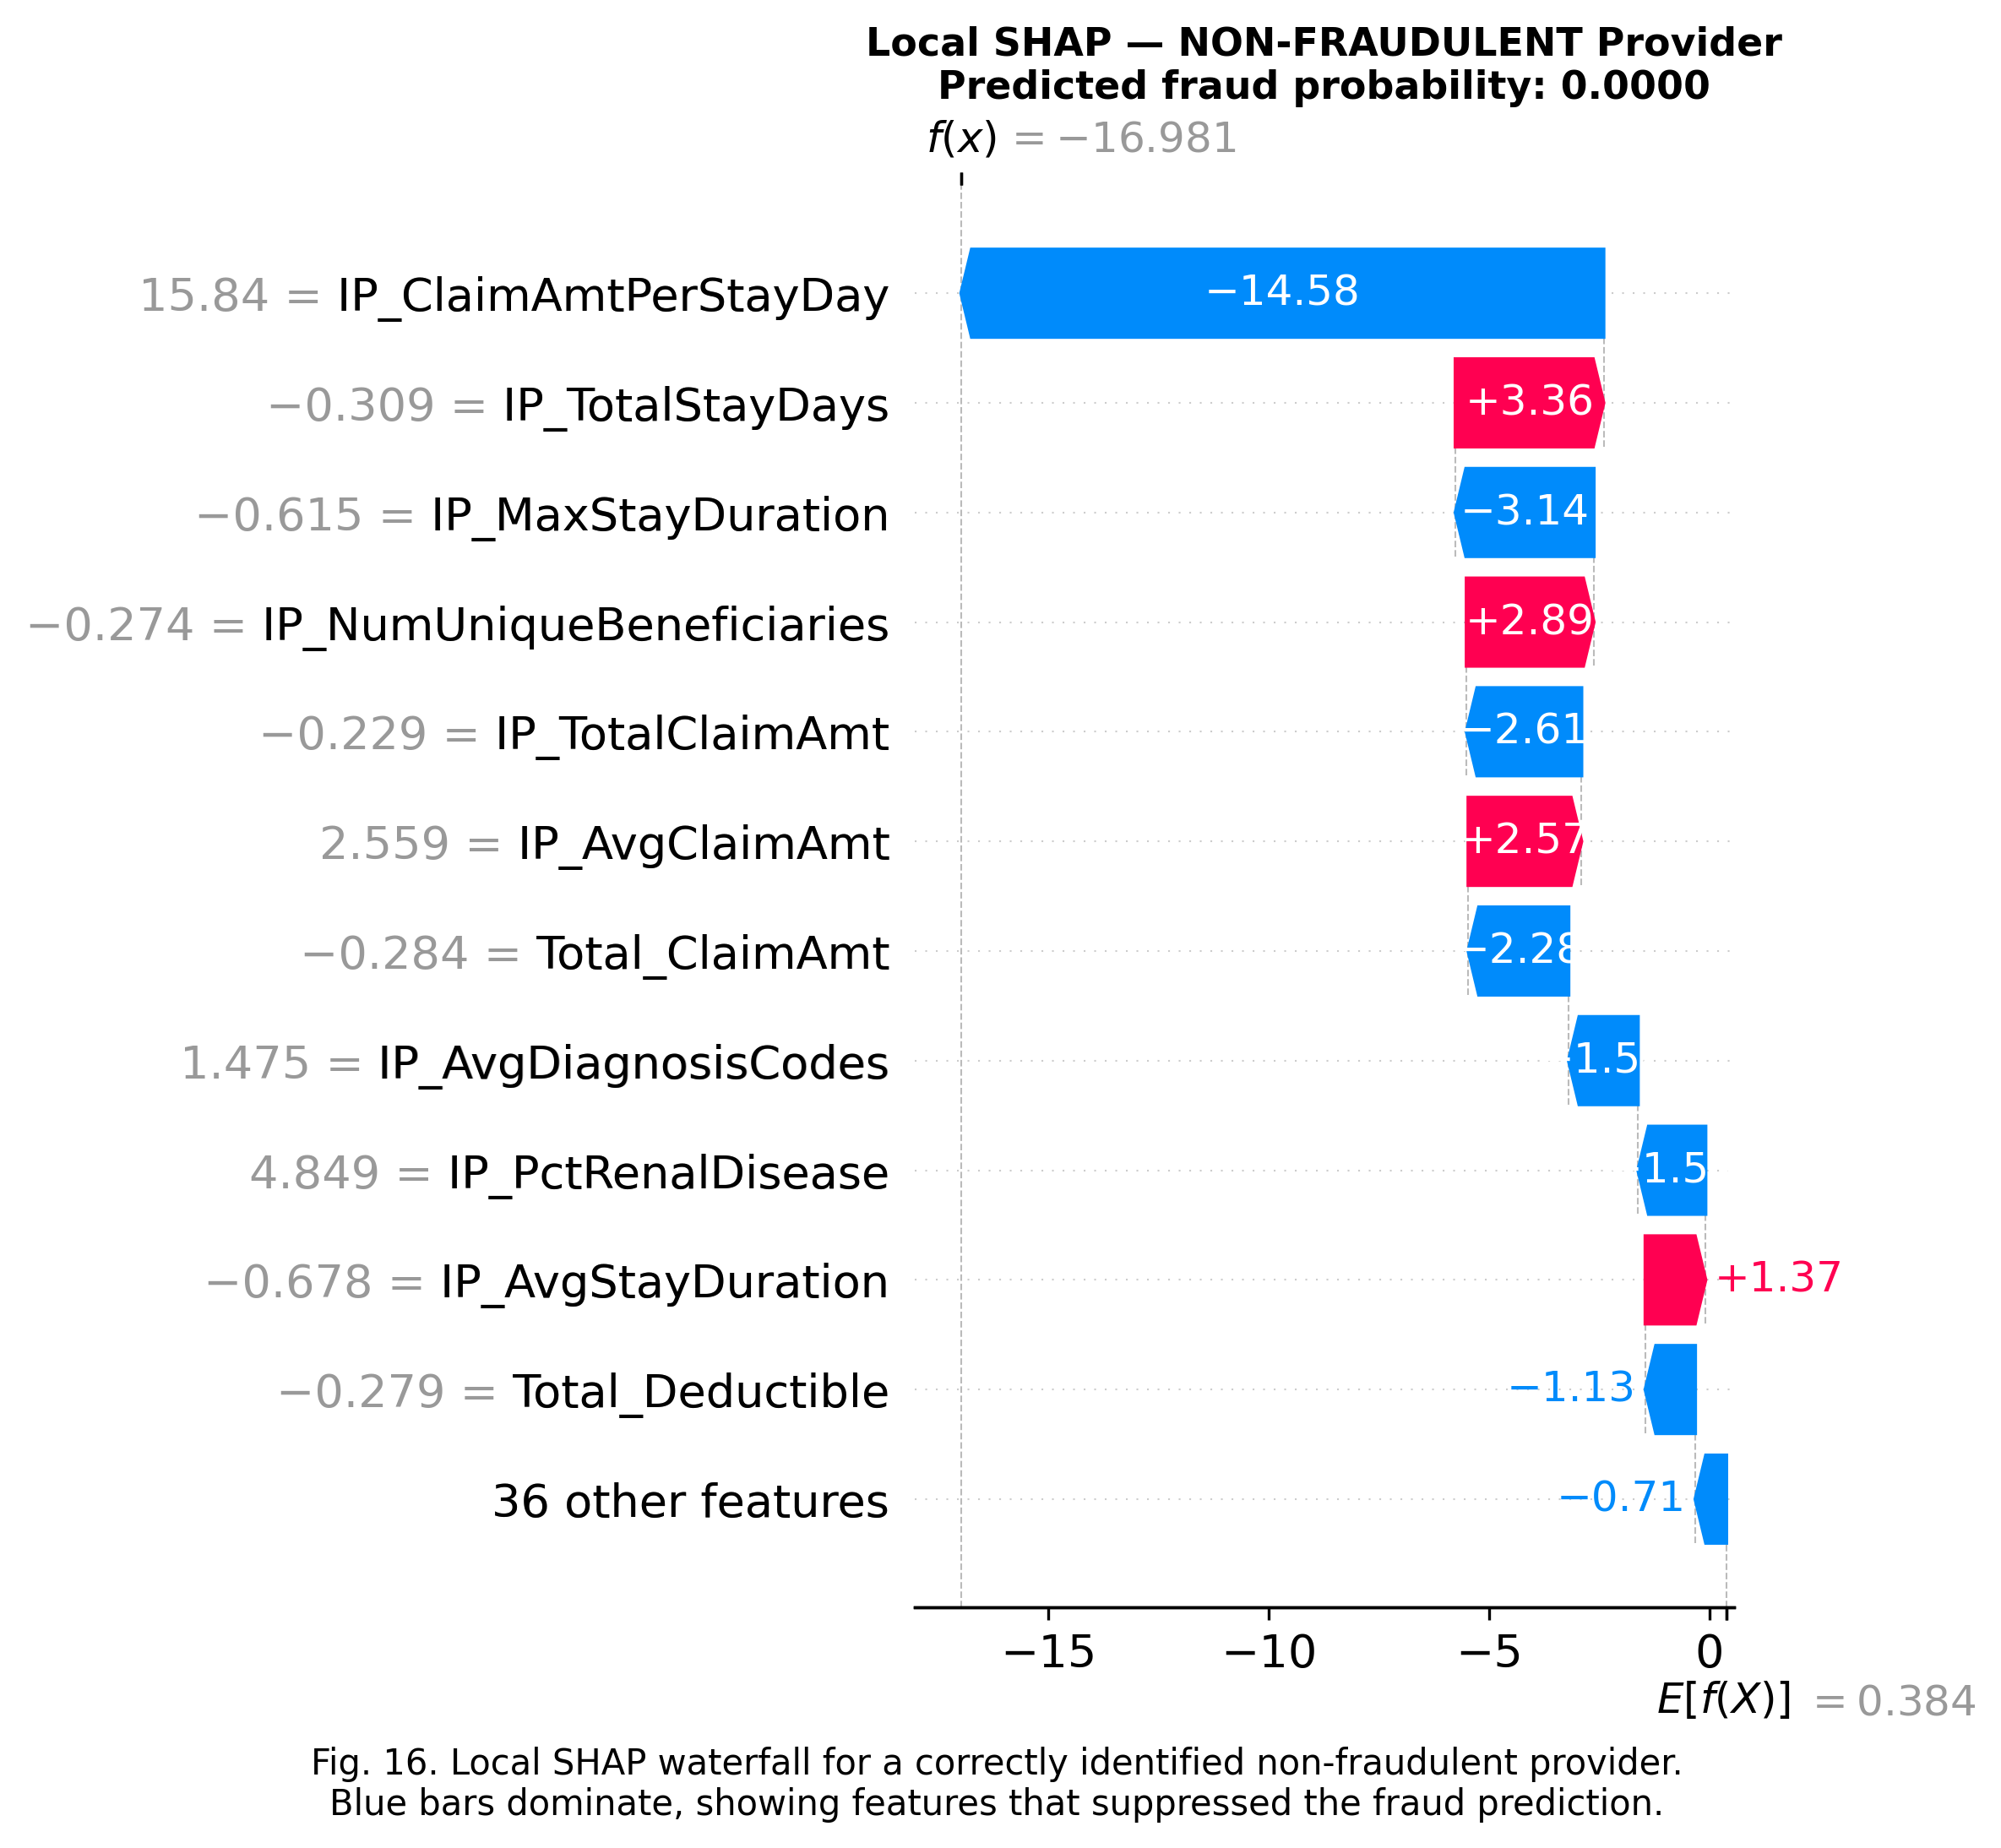

Saved: ../paper/figures/fig16_shap_local_nonfraud.png


In [9]:
# Pick clearest fraud and non-fraud cases from validation set
fraud_indices   = np.where(y_val == 1)[0]
clean_indices   = np.where(y_val == 0)[0]

# Best fraud case: highest predicted fraud probability
lr_proba_val  = lr_model.predict_proba(X_val)[:, 1]
best_fraud_idx = fraud_indices[np.argmax(lr_proba_val[fraud_indices])]
best_clean_idx = clean_indices[np.argmin(lr_proba_val[clean_indices])]

print(f"Selected fraud provider:     val index {best_fraud_idx}, "
      f"fraud prob = {lr_proba_val[best_fraud_idx]:.4f}")
print(f"Selected non-fraud provider: val index {best_clean_idx}, "
      f"fraud prob = {lr_proba_val[best_clean_idx]:.4f}")

# ── Waterfall plot — FRAUD case ─────────────────────────────────
fig = plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values        = lr_shap_values[best_fraud_idx],
        base_values   = lr_explainer.expected_value,
        data          = X_val[best_fraud_idx],
        feature_names = feat_names,
    ),
    max_display=12,
    show=False
)
plt.title(f'Local SHAP — FRAUDULENT Provider\n'
          f'Predicted fraud probability: {lr_proba_val[best_fraud_idx]:.4f}',
          fontsize=11, fontweight='bold')
plt.suptitle(
    'Fig. 15. Local SHAP waterfall for a correctly identified fraudulent provider.\n'
    'Red bars = features pushing prediction toward fraud. Blue = pushing toward non-fraud.',
    fontsize=10, y=0.01
)
plt.tight_layout()
plt.savefig(FIG + 'fig15_shap_local_fraud.png')
plt.show()
print(f"Saved: {FIG}fig15_shap_local_fraud.png")

# ── Waterfall plot — NON-FRAUD case ────────────────────────────
fig = plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values        = lr_shap_values[best_clean_idx],
        base_values   = lr_explainer.expected_value,
        data          = X_val[best_clean_idx],
        feature_names = feat_names,
    ),
    max_display=12,
    show=False
)
plt.title(f'Local SHAP — NON-FRAUDULENT Provider\n'
          f'Predicted fraud probability: {lr_proba_val[best_clean_idx]:.4f}',
          fontsize=11, fontweight='bold')
plt.suptitle(
    'Fig. 16. Local SHAP waterfall for a correctly identified non-fraudulent provider.\n'
    'Blue bars dominate, showing features that suppressed the fraud prediction.',
    fontsize=10, y=0.01
)
plt.tight_layout()
plt.savefig(FIG + 'fig16_shap_local_nonfraud.png')
plt.show()
print(f"Saved: {FIG}fig16_shap_local_nonfraud.png")

Generating force plot for fraud case...


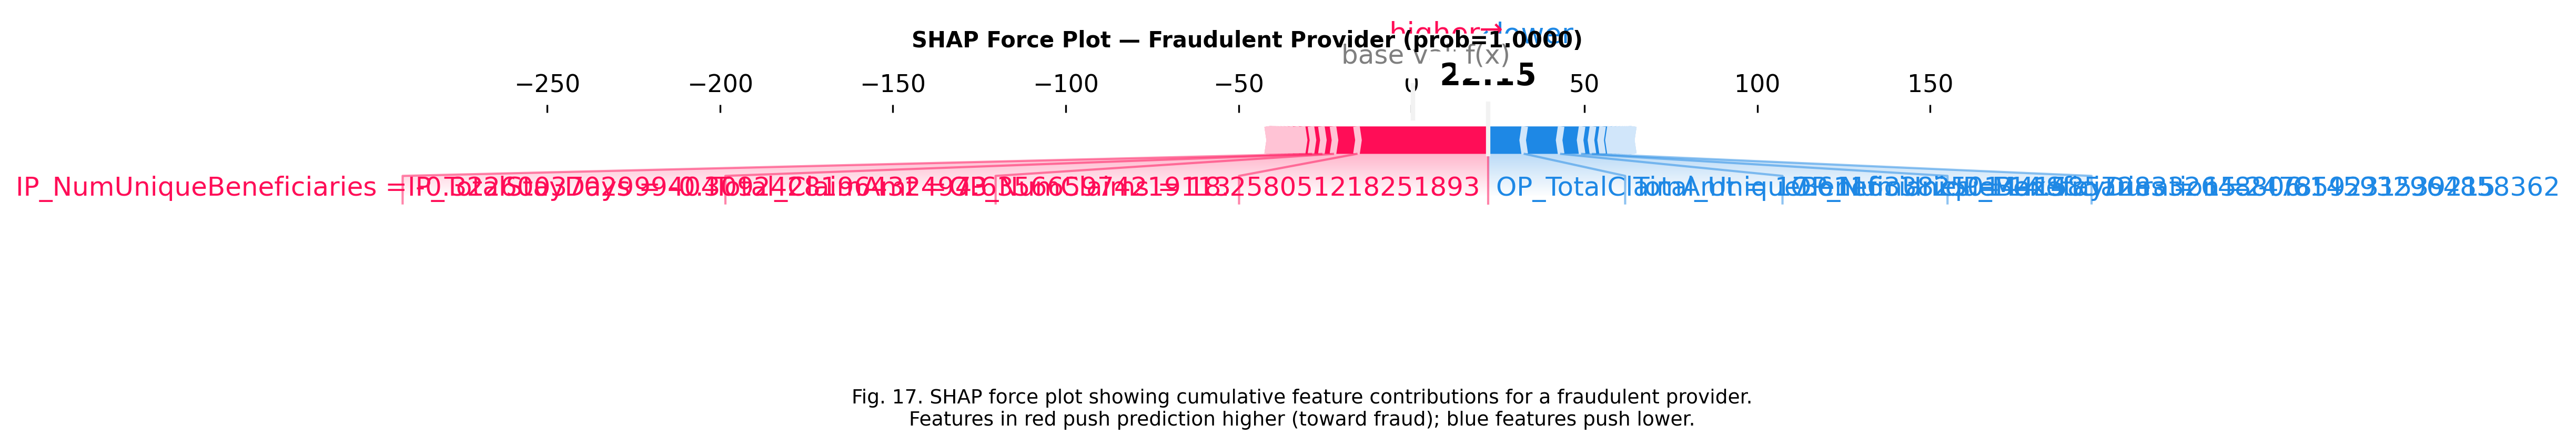

Saved: ../paper/figures/fig17_shap_force_fraud.png


In [10]:
# Force plot — fraud case — shows cumulative feature contributions
print("Generating force plot for fraud case...")

shap.initjs()

force = shap.force_plot(
    lr_explainer.expected_value,
    lr_shap_values[best_fraud_idx],
    X_val[best_fraud_idx],
    feature_names=feat_names,
    show=False,
    matplotlib=True,
    figsize=(16, 3),
)
plt.title(f'SHAP Force Plot — Fraudulent Provider '
          f'(prob={lr_proba_val[best_fraud_idx]:.4f})',
          fontsize=10, pad=30)
plt.suptitle(
    'Fig. 17. SHAP force plot showing cumulative feature contributions for a fraudulent provider.\n'
    'Features in red push prediction higher (toward fraud); blue features push lower.',
    fontsize=9, y=-0.15
)
plt.tight_layout()
plt.savefig(FIG + 'fig17_shap_force_fraud.png', bbox_inches='tight')
plt.show()
print(f"Saved: {FIG}fig17_shap_force_fraud.png")

In [12]:
import json

# Save SHAP values as numpy arrays for dashboard use
np.save(PROC + 'lr_shap_values_val.npy',  lr_shap_values)
np.save(PROC + 'rf_shap_values_val.npy',  rf_shap_fraud)
np.save(PROC + 'lr_expected_value.npy',
        np.array([lr_explainer.expected_value]))
np.save(PROC + 'rf_expected_value.npy',
        np.array([rf_explainer.expected_value[1]]))

# Save top features summary for paper and dashboard
top10_lr = [
    {'rank': i+1,
     'feature': feat_names[idx],
     'mean_shap': float(lr_mean_shap[idx])}
    for i, idx in enumerate(lr_top15_idx[:10])
]
top10_rf = [
    {'rank': i+1,
     'feature': feat_names[idx],
     'mean_shap': float(rf_mean_shap[idx])}
    for i, idx in enumerate(rf_top15_idx[:10])
]

shap_summary = {
    'lr_top10': top10_lr,
    'rf_top10': top10_rf,
    'lr_expected_value': float(lr_explainer.expected_value),
    'rf_expected_value': float(rf_explainer.expected_value[1]),
    'common_top15_features': sorted(list(common)),
    'n_val_samples': int(X_val.shape[0]),
    'n_features': len(feat_names),
}

with open(RES + 'shap_summary.json', 'w') as f:
    json.dump(shap_summary, f, indent=2)

print("=" * 60)
print("PHASE 4 COMPLETE — SHAP SUMMARY FOR YOUR PAPER")
print("=" * 60)

print(f"\nTop 10 features — Logistic Regression:")
print(f"{'Rank':<6} {'Feature':<40} {'Mean |SHAP|'}")
print("-" * 58)
for r in top10_lr:
    print(f"  {r['rank']:<4} {r['feature']:<40} {r['mean_shap']:.4f}")

print(f"\nTop 10 features — Random Forest:")
print(f"{'Rank':<6} {'Feature':<40} {'Mean |SHAP|'}")
print("-" * 58)
for r in top10_rf:
    print(f"  {r['rank']:<4} {r['feature']:<40} {r['mean_shap']:.4f}")

print(f"\nFeatures in top 15 of BOTH models ({len(common)}):")
for f in sorted(common):
    print(f"  {f}")

print(f"\nFiles saved:")
for f in ['lr_shap_values_val.npy','rf_shap_values_val.npy',
          'lr_expected_value.npy','rf_expected_value.npy']:
    print(f"  data/processed/{f}")
print(f"  results/shap_summary.json")

print(f"\nFigures saved:")
for i in range(10, 18):
    matches = [f for f in os.listdir(FIG) if f.startswith(f'fig{i:02d}')]
    for m in matches:
        print(f"  paper/figures/{m}")



PHASE 4 COMPLETE — SHAP SUMMARY FOR YOUR PAPER

Top 10 features — Logistic Regression:
Rank   Feature                                  Mean |SHAP|
----------------------------------------------------------
  1    IP_TotalStayDays                         3.2902
  2    IP_NumUniqueBeneficiaries                2.9287
  3    IP_TotalClaimAmt                         2.7149
  4    IP_MaxStayDuration                       2.6530
  5    Total_ClaimAmt                           2.2807
  6    IP_ClaimsPerPatient                      1.8432
  7    IP_AvgDiagnosisCodes                     1.5800
  8    OP_NumClaims                             1.3739
  9    IP_AvgStayDuration                       1.1653
  10   IP_AvgClaimAmt                           1.1563

Top 10 features — Random Forest:
Rank   Feature                                  Mean |SHAP|
----------------------------------------------------------
  1    IP_MaxStayDuration                       0.0660
  2    Total_ClaimAmt               